In [1]:
#import and formatting statements
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from umap import UMAP
from sklearn.cluster import KMeans
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull
import random
from scipy.stats import kruskal
import scikit_posthocs as sp
from itertools import combinations
from scipy.stats import ks_2samp
from scipy.stats import gaussian_kde
import re


file_path = "Source_Data_CXCL12_placenta.xlsx"
df = pd.read_excel(file_path, sheet_name="Fig_3C+D_Extended_4B", header=None)

plt.rcParams['pdf.fonttype'] = 42

<h2> Figure 3C</h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97897/2559248849.py:30: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


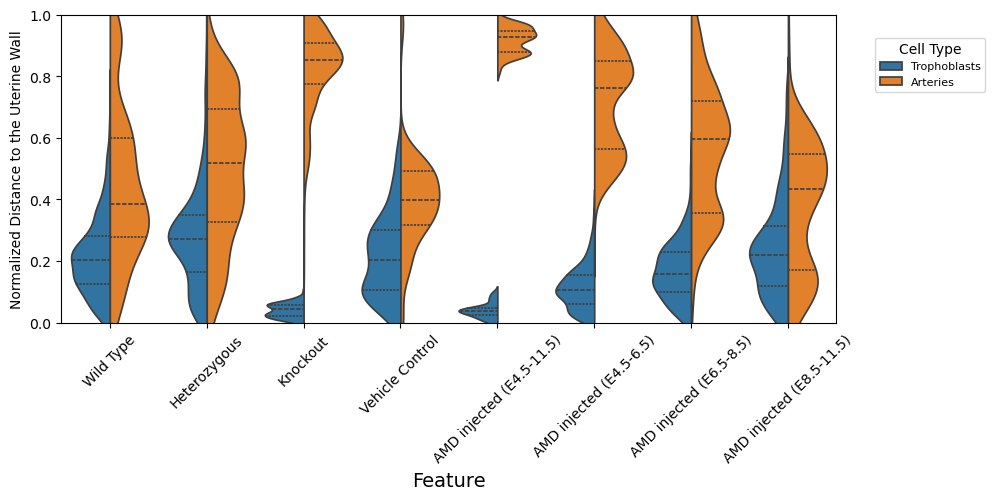

Saved plot: comparison_violin.pdf


In [2]:
treatments = df.iloc[0, 1:]
row_labels = df.iloc[:, 0]

data_artery_all = df[row_labels == 'artery'].iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
data_tropho_all = df[row_labels == 'trophoblast'].iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

custom_order = ["Wild Type", "Heterozygous", "Knockout","Vehicle Control", "AMD injected (E4.5-11.5)", "AMD injected (E4.5-6.5)", "AMD injected (E6.5-8.5)", "AMD injected (E8.5-11.5)"]

plot_data = [ ]

for treatment in custom_order:
    col_indices = treatments[treatments == treatment].index
    
    vals_artery = data_artery_all[col_indices].values.flatten()
    vals_artery = vals_artery[~np.isnan(vals_artery)]  
    vals_artery = np.clip(vals_artery, 0, None)       
    
    vals_tropho = data_tropho_all[col_indices].values.flatten()
    vals_tropho = vals_tropho[~np.isnan(vals_tropho)]
    vals_tropho = np.clip(vals_tropho, 0, None)
    
    if len(vals_artery) > 0:
        plot_data.append(pd.DataFrame({'Value': vals_artery, 'Feature': treatment, 'Source': 'Arteries'}))
    if len(vals_tropho) > 0:
        plot_data.append(pd.DataFrame({'Value': vals_tropho, 'Feature': treatment, 'Source': 'Trophoblasts'}))

plot_data_df = pd.concat(plot_data, ignore_index=True)

plt.figure(figsize=(10, 4))
sns.violinplot(
    x="Feature", y="Value", hue="Source",
    data=plot_data_df, scale="width", inner="quart", split=True,
    order=custom_order,
    hue_order = ['Trophoblasts', 'Arteries'],
)

plt.ylim(bottom=0, top=1)
plt.xlabel("Feature", fontsize=14)
plt.ylabel("Normalized Distance to the Uterine Wall", fontsize=10)
plt.xticks(rotation=45)
plt.legend(title="Cell Type", fontsize=8, title_fontsize=10, loc=(1.05, 0.75))

plot_filename = f"comparison_violin.pdf"
#plt.savefig(plot_filename, dpi=300, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved plot: {plot_filename}")

<h2> Figure 3D</h2>

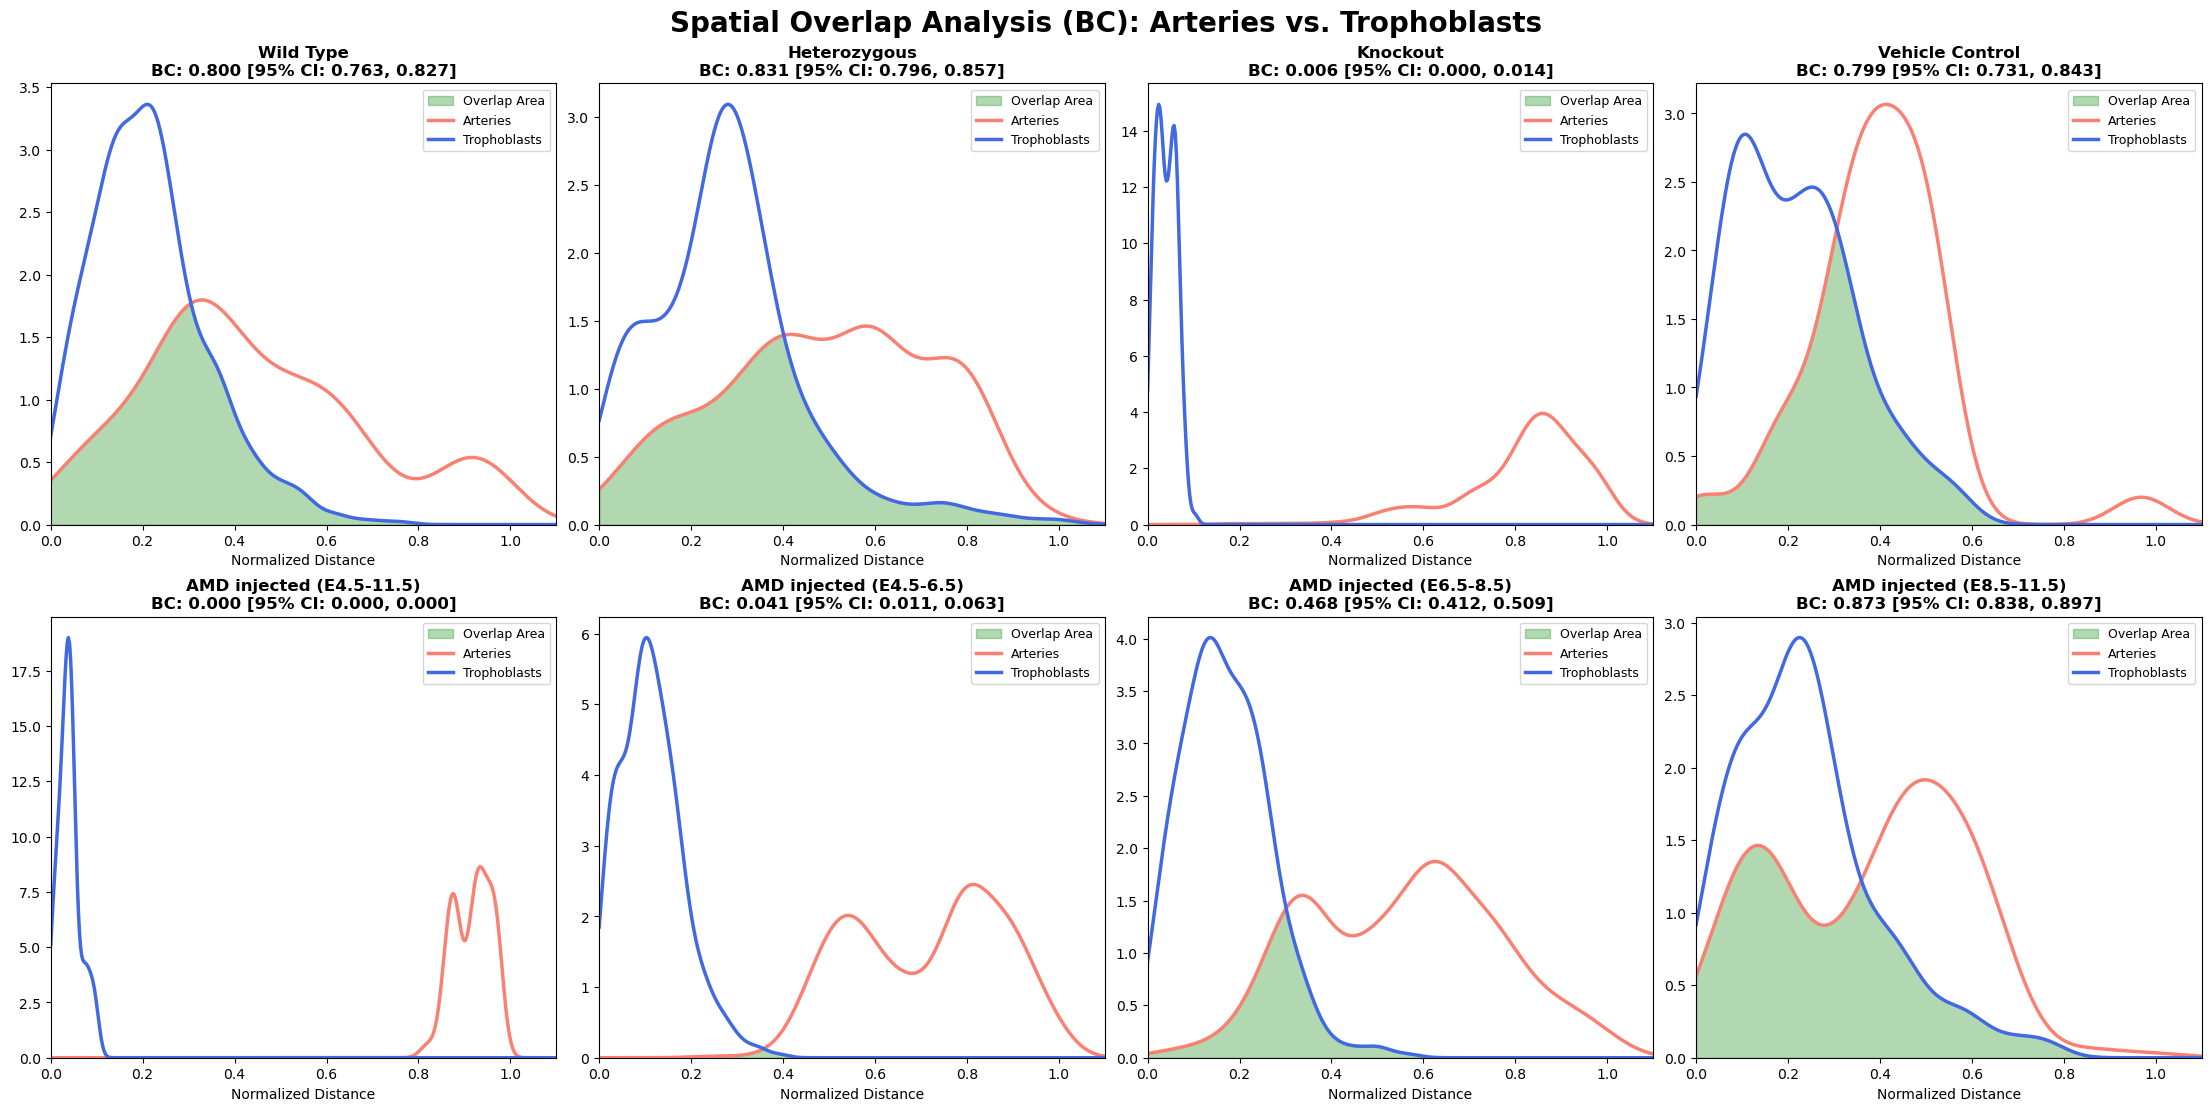

In [3]:
treatments_row = df.iloc[0, 1:]
row_labels = df.iloc[:, 0]

data_artery_all = df[row_labels.str.strip() == 'artery'].iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
data_tropho_all = df[row_labels.str.strip() == 'trophoblast'].iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

custom_order = [
    "Wild Type", "Heterozygous", "Knockout", "Vehicle Control", 
    "AMD injected (E4.5-11.5)", "AMD injected (E4.5-6.5)", 
    "AMD injected (E6.5-8.5)", "AMD injected (E8.5-11.5)"
]

x_grid = np.linspace(0, 1.2, 500) 
n_bootstraps = 1000
np.random.seed(44) 

def calc_bc(d1, d2):
    """Calculates Bhattacharyya Coefficient using grid integration"""
    try:
        k1 = gaussian_kde(d1)(x_grid)
        k2 = gaussian_kde(d2)(x_grid)
        return np.trapz(np.sqrt(k1 * k2), x_grid)
    except:
        return 0.0

fig, axes = plt.subplots(2, 4, figsize=(22, 11), constrained_layout=True)
axes_flat = axes.flatten()

for i, treatment in enumerate(custom_order):
    ax = axes_flat[i]
    
    col_indices = treatments_row[treatments_row == treatment].index
    
    art_vals = data_artery_all[col_indices].values.flatten()
    art_vals = art_vals[~np.isnan(art_vals)]
    art_vals = np.clip(art_vals, 0, None)
    
    tropho_vals = data_tropho_all[col_indices].values.flatten()
    tropho_vals = tropho_vals[~np.isnan(tropho_vals)]
    tropho_vals = np.clip(tropho_vals, 0, None)
    
    if len(art_vals) > 1 and len(tropho_vals) > 1:
        bc_obs = calc_bc(art_vals, tropho_vals)
        
        boot_bcs = []
        for _ in range(n_bootstraps):
            s_art = np.random.choice(art_vals, size=len(art_vals), replace=True)
            s_tropho = np.random.choice(tropho_vals, size=len(tropho_vals), replace=True)
            boot_bcs.append(calc_bc(s_art, s_tropho))
            
        ci_low = np.percentile(boot_bcs, 2.5)
        ci_high = np.percentile(boot_bcs, 97.5)
        
        kde_art = gaussian_kde(art_vals)(x_grid)
        kde_tropho = gaussian_kde(tropho_vals)(x_grid)
        overlap = np.minimum(kde_art, kde_tropho)
        
        ax.fill_between(x_grid, overlap, color='green', alpha=0.3, label='Overlap Area')
        ax.plot(x_grid, kde_art, color='salmon', lw=2.5, label='Arteries')
        ax.plot(x_grid, kde_tropho, color='royalblue', lw=2.5, label='Trophoblasts')
        
        ax.set_title(f"{treatment}\nBC: {bc_obs:.3f} [95% CI: {ci_low:.3f}, {ci_high:.3f}]", 
                     fontsize=12, weight='bold')
        ax.set_xlim(0, 1.1)
        ax.set_ylim(bottom=0)
        ax.set_xlabel("Normalized Distance", fontsize=10)
        ax.legend(fontsize=9, loc='upper right')
    else:
        ax.axis('off')

plt.suptitle("Spatial Overlap Analysis (BC): Arteries vs. Trophoblasts", fontsize=20, weight='bold')
plt.savefig("BC_Overlap_Analysis_2x4.pdf", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97897/1938500793.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(
/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97897/1938500793.py:34: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(
/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97897/1938500793.py:34: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


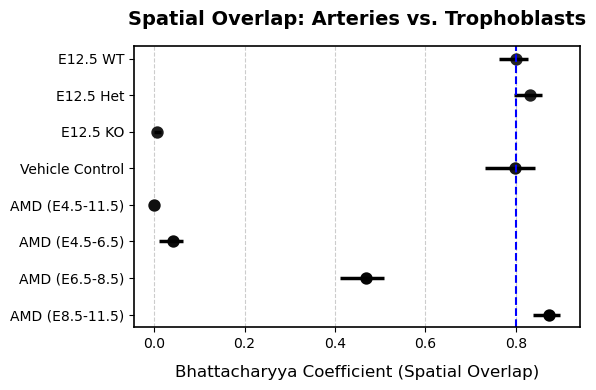

In [4]:
data = {
    'E12.5': {
        'WT': {'median': 0.800, 'lower': 0.763, 'upper': 0.827},
        'Het': {'median': 0.831, 'lower': 0.796, 'upper': 0.857},
        'KO': {'median': 0.006, 'lower': 0.000, 'upper': 0.014}
    },
    'AMD Treatments': {
        'Vehicle Control': {'median': 0.799, 'lower': 0.731, 'upper': 0.843},
        'AMD (E4.5-11.5)': {'median': 0.000, 'lower': 0.000, 'upper': 0.000},
        'AMD (E4.5-6.5)':  {'median': 0.041, 'lower': 0.011, 'upper': 0.063},
        'AMD (E6.5-8.5)':  {'median': 0.468, 'lower': 0.412, 'upper': 0.509},
        'AMD (E8.5-11.5)': {'median': 0.873, 'lower': 0.838, 'upper': 0.897}
    }
}

rows = []
for group, genotypes in data.items():
    for genotype, vals in genotypes.items():
        rows.append({
            'Group': group,
            'Genotype': genotype,
            'BC': vals['median'],
            'Lower': vals['lower'],
            'Upper': vals['upper'],
            'Label': f"{group} {genotype}" if group != 'AMD Treatments' else genotype
        })

df = pd.DataFrame(rows)

plt.figure(figsize=(6, 4))

errors = [df['BC'] - df['Lower'], df['Upper'] - df['BC']]

ax = sns.pointplot(
    data=df, 
    x="BC", 
    y="Label",
    palette="dark:black",
    join=False,
    markers="o",
    scale=1.2 
)

plt.errorbar(
    x=df['BC'], 
    y=df['Label'], 
    xerr=errors, 
    fmt='none', 
    c='black', 
    linewidth=2.5, 
    capsize=0
)

ax.set_xlabel('Bhattacharyya Coefficient (Spatial Overlap)', fontsize=12, labelpad=10)
ax.set_ylabel('')
ax.set_title('Spatial Overlap: Arteries vs. Trophoblasts', fontsize=14, weight='bold', pad=15)

ax.xaxis.grid(True, linestyle='--', color='gray', alpha=0.4, zorder=0)

ax.axvline(x=0.800, color='blue', linestyle='--', alpha=1, linewidth=1.5)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

plt.tight_layout()

plt.savefig("forest_plot_all_treatments.pdf", dpi=300, bbox_inches='tight')
plt.show()